In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split, StratifiedKFold, RandomizedSearchCV, GridSearchCV
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.metrics import classification_report, roc_auc_score
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.svm import SVC
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
import joblib
import shap

c:\Users\LENOVO\Documents\Student-Performance-Predictor\studentproject_venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
#concatenating the two datasets

df = pd.concat([pd.read_csv(r"../data/student-mat.csv", sep=";"), pd.read_csv(r"../data/student-por.csv", sep=";")], ignore_index=True)
df = df.copy()


In [3]:
df[["sex", "age", "address", "famsize", "Pstatus", "guardian", "traveltime", "studytime", "failures", "schoolsup", "famsup", "activities", "nursery", "famrel", "health", "absences", "freetime", "goout", "internet", "romantic"]].head()


,sex,age,address,famsize,Pstatus,guardian,traveltime,studytime,failures,schoolsup,famsup,activities,nursery,famrel,health,absences,freetime,goout,internet,romantic
0,F,18,U,GT3,A,mother,2,2,0,yes,no,no,yes,4,3,6,3,4,no,no
1,F,17,U,GT3,T,father,1,2,0,no,yes,no,no,5,3,4,3,3,yes,no
2,F,15,U,LE3,T,mother,1,2,3,yes,no,no,yes,4,3,10,3,2,yes,no
3,F,15,U,GT3,T,mother,1,3,0,no,yes,yes,yes,3,5,2,2,2,yes,yes
4,F,16,U,GT3,T,father,1,2,0,no,yes,no,yes,4,5,4,3,2,no,no


In [4]:
df["schoolsup"].unique()

<StringArray>
['yes', 'no']
Length: 2, dtype: str

In [5]:
#column dropping
df.drop(columns = ['higher', 
                   'Mjob', 'Fjob', 'reason',
                     'paid'], inplace = True)

In [6]:
#more dropping

df.drop(columns=["school", "Medu", "Fedu", "Dalc", "Walc"], inplace=True) 

df["label"] = (df["G3"] >= 10).astype(int) #binary level classification; if g3>=10 then 1(pass) else 0(fail)

df.drop(columns=["G1","G2","G3"], inplace=True) #only label column is g3, dropping g1 and g2

In [53]:
df.shape

(1044, 21)

In [7]:
#getting categorical and numerical columns. Numerical columns will be scaled and categorical columns will be encoded.

cat_cols = df.select_dtypes(include=["object"]).columns.tolist()
num_cols = df.select_dtypes(include=["int64","float64"]).columns.difference(["label"]).tolist()




C:\Users\LENOVO\AppData\Local\Temp\ipykernel_16132\4131541602.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include=["object"]).columns.tolist()


In [8]:
#splitting data for models
X_train, X_test, y_train, y_test = train_test_split(
    df.drop(columns=["label"]), df["label"],
    test_size=0.2, random_state=42, stratify=df["label"]

)



#preprocessing categorical and numerical features for all models

preproc = ColumnTransformer([
    ("num", StandardScaler(), num_cols),
    ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output = False), cat_cols),
])

preproc.set_output(transform="pandas")

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``. e.g. `

In [18]:
# X_train = preproc.fit_transform(X_train)
# X_test = preproc.transform(X_test)

In [17]:
#Pipeline for Random Forest Classifier
pipe_rf = ImbPipeline([
    ("pre", preproc),
    ("smote", SMOTE(random_state=42)),
    ("clf", RandomForestClassifier(random_state=42, n_jobs=-1)),
])
param_dist_rf = {
    "clf__n_estimators": [100, 200, 500],
    "clf__max_depth": [None, 8, 12, 20],
    "clf__min_samples_leaf": [1, 2, 4],
    "clf__max_features": ["sqrt", "log2", 0.5],
    "clf__class_weight": ["balanced", "balanced_subsample", None]
}
search_rf = GridSearchCV(pipe_rf, param_grid=param_dist_rf, scoring="roc_auc", cv=StratifiedKFold(5), n_jobs=-1, verbose=1, refit=True)
search_rf.fit(X_train, y_train)
rf_model = search_rf.best_estimator_  # This is the tuned RF pipeline

Fitting 5 folds for each of 324 candidates, totalling 1620 fits


ValueError: 
All the 1620 fits failed.
It is very likely that your model is misconfigured.
You can try to debug the error by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
1620 fits failed with the following error:
Traceback (most recent call last):
  File "c:\Users\LENOVO\Documents\Student-Performance-Predictor\studentproject_venv\Lib\site-packages\pandas\core\indexes\base.py", line 3641, in get_loc
    return self._engine.get_loc(casted_key)
           ~~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^
  File "pandas/_libs/index.pyx", line 168, in pandas._libs.index.IndexEngine.get_loc
  File "pandas/_libs/index.pyx", line 197, in pandas._libs.index.IndexEngine.get_loc
  File "pandas/_libs/hashtable_class_helper.pxi", line 7668, in pandas._libs.hashtable.PyObjectHashTable.get_item
  File "pandas/_libs/hashtable_class_helper.pxi", line 7676, in pandas._libs.hashtable.PyObjectHashTable.get_item
KeyError: 'absences'

The above exception was the direct cause of the following exception:

Traceback (most recent call last):
  File "c:\Users\LENOVO\Documents\Student-Performance-Predictor\studentproject_venv\Lib\site-packages\sklearn\utils\_indexing.py", line 469, in _get_column_indices
    col_idx = all_columns.get_loc(col)
  File "c:\Users\LENOVO\Documents\Student-Performance-Predictor\studentproject_venv\Lib\site-packages\pandas\core\indexes\base.py", line 3648, in get_loc
    raise KeyError(key) from err
KeyError: 'absences'

The above exception was the direct cause of the following exception:

Traceback (most recent call last):
  File "c:\Users\LENOVO\Documents\Student-Performance-Predictor\studentproject_venv\Lib\site-packages\sklearn\model_selection\_validation.py", line 833, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
    ~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\LENOVO\Documents\Student-Performance-Predictor\studentproject_venv\Lib\site-packages\sklearn\base.py", line 1336, in wrapper
    return fit_method(estimator, *args, **kwargs)
  File "c:\Users\LENOVO\Documents\Student-Performance-Predictor\studentproject_venv\Lib\site-packages\imblearn\pipeline.py", line 514, in fit
    Xt, yt = self._fit(X, y, routed_params, raw_params=params)
             ~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\LENOVO\Documents\Student-Performance-Predictor\studentproject_venv\Lib\site-packages\imblearn\pipeline.py", line 426, in _fit
    X, fitted_transformer = fit_transform_one_cached(
                            ~~~~~~~~~~~~~~~~~~~~~~~~^
        cloned_transformer,
        ^^^^^^^^^^^^^^^^^^^
    ...<5 lines>...
        params=step_params,
        ^^^^^^^^^^^^^^^^^^^
    )
    ^
  File "c:\Users\LENOVO\Documents\Student-Performance-Predictor\studentproject_venv\Lib\site-packages\joblib\memory.py", line 326, in __call__
    return self.func(*args, **kwargs)
           ~~~~~~~~~^^^^^^^^^^^^^^^^^
  File "c:\Users\LENOVO\Documents\Student-Performance-Predictor\studentproject_venv\Lib\site-packages\imblearn\pipeline.py", line 1379, in _fit_transform_one
    res = transformer.fit_transform(X, y, **params.get("fit_transform", {}))
  File "c:\Users\LENOVO\Documents\Student-Performance-Predictor\studentproject_venv\Lib\site-packages\sklearn\utils\_set_output.py", line 316, in wrapped
    data_to_wrap = f(self, X, *args, **kwargs)
  File "c:\Users\LENOVO\Documents\Student-Performance-Predictor\studentproject_venv\Lib\site-packages\sklearn\base.py", line 1336, in wrapper
    return fit_method(estimator, *args, **kwargs)
  File "c:\Users\LENOVO\Documents\Student-Performance-Predictor\studentproject_venv\Lib\site-packages\sklearn\compose\_column_transformer.py", line 991, in fit_transform
    self._validate_column_callables(X)
    ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~^^^
  File "c:\Users\LENOVO\Documents\Student-Performance-Predictor\studentproject_venv\Lib\site-packages\sklearn\compose\_column_transformer.py", line 545, in _validate_column_callables
    transformer_to_input_indices[name] = _get_column_indices(X, columns)
                                         ~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^
  File "c:\Users\LENOVO\Documents\Student-Performance-Predictor\studentproject_venv\Lib\site-packages\sklearn\utils\_indexing.py", line 477, in _get_column_indices
    raise ValueError("A given column is not a column of the dataframe") from e
ValueError: A given column is not a column of the dataframe


In [9]:
# Pipeline for Gradient Boosting Classifier
pipe_gb = ImbPipeline([
    ("pre", preproc),
    ("smote", SMOTE(random_state=42)),
    ("clf", GradientBoostingClassifier(random_state=42)),
])
param_dist_gb = {
    "clf__n_estimators": [100, 200, 300],
    "clf__max_depth": [3, 5, 7],
    "clf__learning_rate": [0.01, 0.05, 0.1],
    "clf__subsample": [0.7, 0.8, 0.9],
    "clf__min_samples_split": [2, 5, 10],
    "clf__min_samples_leaf": [1, 2, 4],
}
search_gb = GridSearchCV(pipe_gb, param_grid=param_dist_gb, scoring="roc_auc", cv=StratifiedKFold(5), n_jobs=-1, verbose=1, refit=True)
search_gb.fit(X_train, y_train)
gb_model = search_gb.best_estimator_  # This is the tuned GB pipeline

Fitting 5 folds for each of 729 candidates, totalling 3645 fits


In [11]:
#Pipeline for Support Vector Machine
pipe_svm = ImbPipeline([
    ("pre", preproc),
    ("smote", SMOTE(random_state=42)),
    ("clf", SVC(random_state=42, probability=True)),
])
param_dist_svm = {
    "clf__C": [0.1, 1, 10],
    "clf__kernel": ["linear", "rbf"],
    "clf__gamma": ["scale", "auto"],
}
search_svm = GridSearchCV(pipe_svm, param_grid=param_dist_svm, scoring="roc_auc", cv=StratifiedKFold(5), n_jobs=-1, verbose=1, refit=True)
search_svm.fit(X_train, y_train)
svm_model = search_svm.best_estimator_  # This is the tuned SVM pipeline

Fitting 5 folds for each of 12 candidates, totalling 60 fits


In [12]:
#ensembling models
from sklearn.ensemble import VotingClassifier

ensemble = VotingClassifier(
    estimators=[('rf', rf_model), ('gb', gb_model), ('svm', svm_model)],
    voting='soft'  # Averages probabilities
)
ensemble.fit(X_train, y_train)  # This combines the trained models without retraining them

,"estimators estimators: list of (str, estimator) tuplesInvoking the ``fit`` method on the ``VotingClassifier`` will fit clonesof those original estimators that will be stored in the class attribute``self.estimators_``. An estimator can be set to ``'drop'`` using:meth:`set_params`... versionchanged:: 0.21 ``'drop'`` is accepted. Using None was deprecated in 0.22 and support was removed in 0.24.","[('rf', ...), ('gb', ...), ...]"
,"voting voting: {'hard', 'soft'}, default='hard'If 'hard', uses predicted class labels for majority rule voting.Else if 'soft', predicts the class label based on the argmax ofthe sums of the predicted probabilities, which is recommended foran ensemble of well-calibrated classifiers.",'soft'
,"weights weights: array-like of shape (n_classifiers,), default=NoneSequence of weights (`float` or `int`) to weight the occurrences ofpredicted class labels (`hard` voting) or class probabilitiesbefore averaging (`soft` voting). Uses uniform weights if `None`.",None
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for ``fit``.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionadded:: 0.18",None
,"flatten_transform flatten_transform: bool, default=TrueAffects shape of transform output only when voting='soft'If voting='soft' and flatten_transform=True, transform method returnsmatrix with shape (n_samples, n_classifiers * n_classes). Ifflatten_transform=False, it returns(n_classifiers, n_samples, n_classes).",True
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting will be printed as itis completed... versionadded:: 0.23",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use

In [13]:
y_pred_ensemble = ensemble.predict(X_test)
print(classification_report(y_test, y_pred_ensemble))
print("ROC AUC:", roc_auc_score(y_test, ensemble.predict_proba(X_test)[:, 1]))

              precision    recall  f1-score   support

           0       0.50      0.30      0.38        46
           1       0.82      0.91      0.87       163

    accuracy                           0.78       209
   macro avg       0.66      0.61      0.62       209
weighted avg       0.75      0.78      0.76       209

ROC AUC: 0.6452387303280874


In [14]:
df["label"].value_counts()

label
1    814
0    230
Name: count, dtype: int64

In [79]:
with open("stud_performance_classifier.joblib", "wb") as f:
    joblib.dump(ensemble, f)

NameError: name 'ensemble' is not defined

In [10]:
data_to_predict = pd.DataFrame({
    "sex": ["M"],
    "age": [24],
    "address": ["R"],
    "famsize": ["LE3"],
    "Pstatus": ["T"],
    "guardian": ["father"],
    "traveltime": [4],
    "studytime": [1],
    "failures": [3],
    "schoolsup": ["yes"],
    "famsup": ["no"],
    "activities": ["no"],
    "nursery": ["yes"],
    "internet": ["no"],
    "romantic": ["yes"],
    "famrel": [1],
    "freetime": [3],
    "goout": [4],
    "health": [1],
    "absences": [6],
    "label": [0]
})


In [87]:
gb_model.predict(data_to_predict.drop(columns=["label"]))

c:\Users\LENOVO\Documents\Student-Performance-Predictor\studentproject_venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but GradientBoostingClassifier was fitted with feature names
  warnings.warn(


array([0])

In [11]:
data_to_predict_transformed = preproc.fit_transform(data_to_predict)

In [89]:
data_to_predict.shape

(1, 21)

In [ ]:
SHAP ANALYSIS

In [11]:
len(df.columns)

21

In [57]:
pipe_gb = Pipeline([
    ("pre", preproc),
    #("smote", SMOTE(random_state=42)),
    ("clf", GradientBoostingClassifier(random_state=42)),
])
param_dist_gb = {
    "clf__n_estimators": [100, 200, 300],
    "clf__max_depth": [3, 5, 7],
    "clf__learning_rate": [0.01, 0.05, 0.1],
    "clf__subsample": [0.7, 0.8, 0.9],
    "clf__min_samples_split": [2, 5, 10],
    "clf__min_samples_leaf": [1, 2, 4],
}
search_gb = GridSearchCV(pipe_gb, param_grid=param_dist_gb, scoring="roc_auc", cv=StratifiedKFold(5), n_jobs=-1, verbose=1, refit=True)
search_gb.fit(X_train, y_train)
gb_model = search_gb.best_estimator_  # This is the tuned GB pipeline

Fitting 5 folds for each of 729 candidates, totalling 3645 fits


In [12]:
y_pred_ensemble = gb_model.predict(X_test)
print(classification_report(y_test, y_pred_ensemble))
print("ROC AUC:", roc_auc_score(y_test, gb_model.predict_proba(X_test)[:, 1]))

              precision    recall  f1-score   support

           0       0.55      0.24      0.33        46
           1       0.81      0.94      0.88       163

    accuracy                           0.79       209
   macro avg       0.68      0.59      0.60       209
weighted avg       0.76      0.79      0.76       209

ROC AUC: 0.6371032275273406


In [13]:
model = gb_model[-1]
gb_model.set_output(transform = "default")


,steps,"[('pre', ...), ('smote', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given st

In [14]:
# Create SHAP explainer (fast for tree models)
explainer = shap.TreeExplainer(model)

# Calculate SHAP values
shap_values = explainer(data_to_predict_transformed, check_additivity = False)



In [15]:
shap_values

.values =
array([[-0.02259812, -0.05473352, -0.87902929, -0.02658488, -0.09095156,
        -0.1306235 , -0.01835272, -0.04272821, -0.02827391,  0.02004454,
        -0.00405284, -0.01957351,  0.00282793, -0.00384161,  0.03806107,
         0.07905282, -0.00241267,  0.17158687, -0.00214084,  0.13000982]])

.base_values =
array([-0.02148073])

.data =
array([[0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 1., 1., 1., 1., 1., 1.,
        1., 1., 1., 1.]])

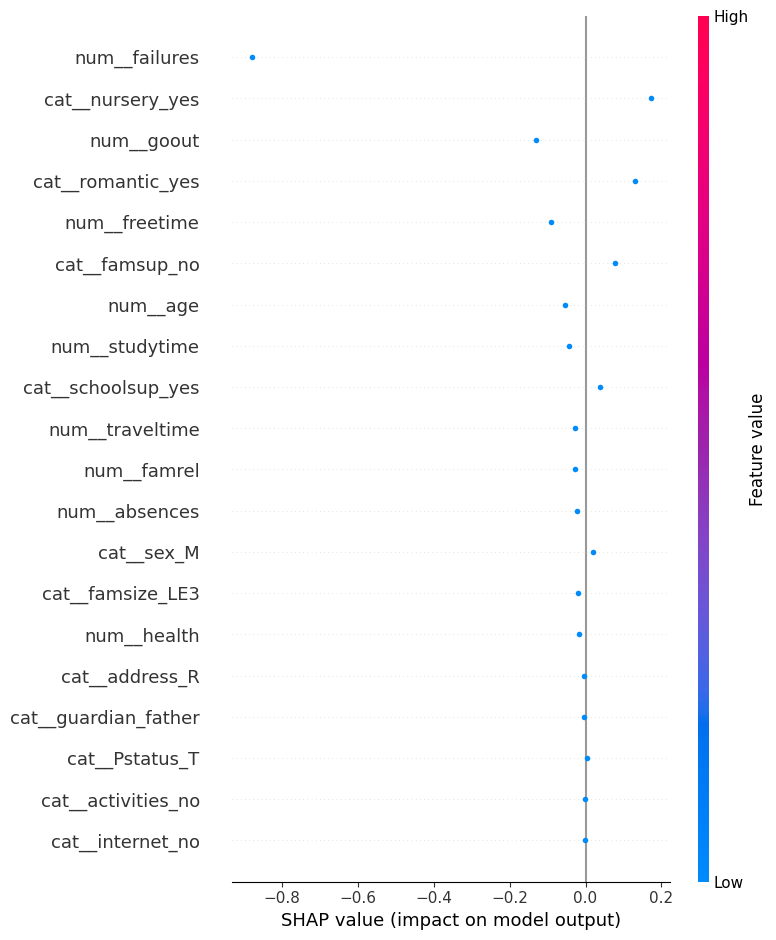

In [20]:
namefeatures = ["past failures", "attended nursery school", "go out often?", "romantic relationship",
                                                                             "freetime",  "family educational support", "age", "studytime", "school educational support",
                                                                             "traveltime", "family relationship quality", "number of absences", "gender", "family size", 
                                                                             "health status", "address type", "guardian", "parents status", "extra-curricular activities", "access to internet"]


# Visualize
shap.summary_plot(shap_values, data_to_predict_transformed)

In [22]:
print(type(shap_values))

<class 'shap._explanation.Explanation'>
